In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('carprices.csv')

In [5]:
df.head()

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Mileage        20 non-null     int64
 1   Age(yrs)       20 non-null     int64
 2   Sell Price($)  20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [9]:
df = df.rename(columns={'Mileage': 'mileage', 'Age(yrs)': 'age_years', 'Sell Price($)': 'sell_price'})

In [10]:
df.head()

,mileage,age_years,sell_price
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500


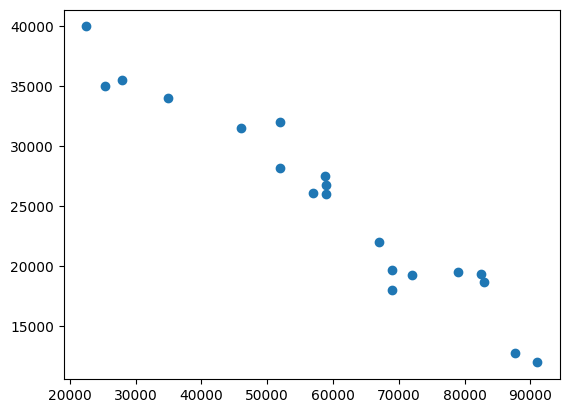

In [15]:
plt.scatter(df['mileage'], df['sell_price'])
plt.show()

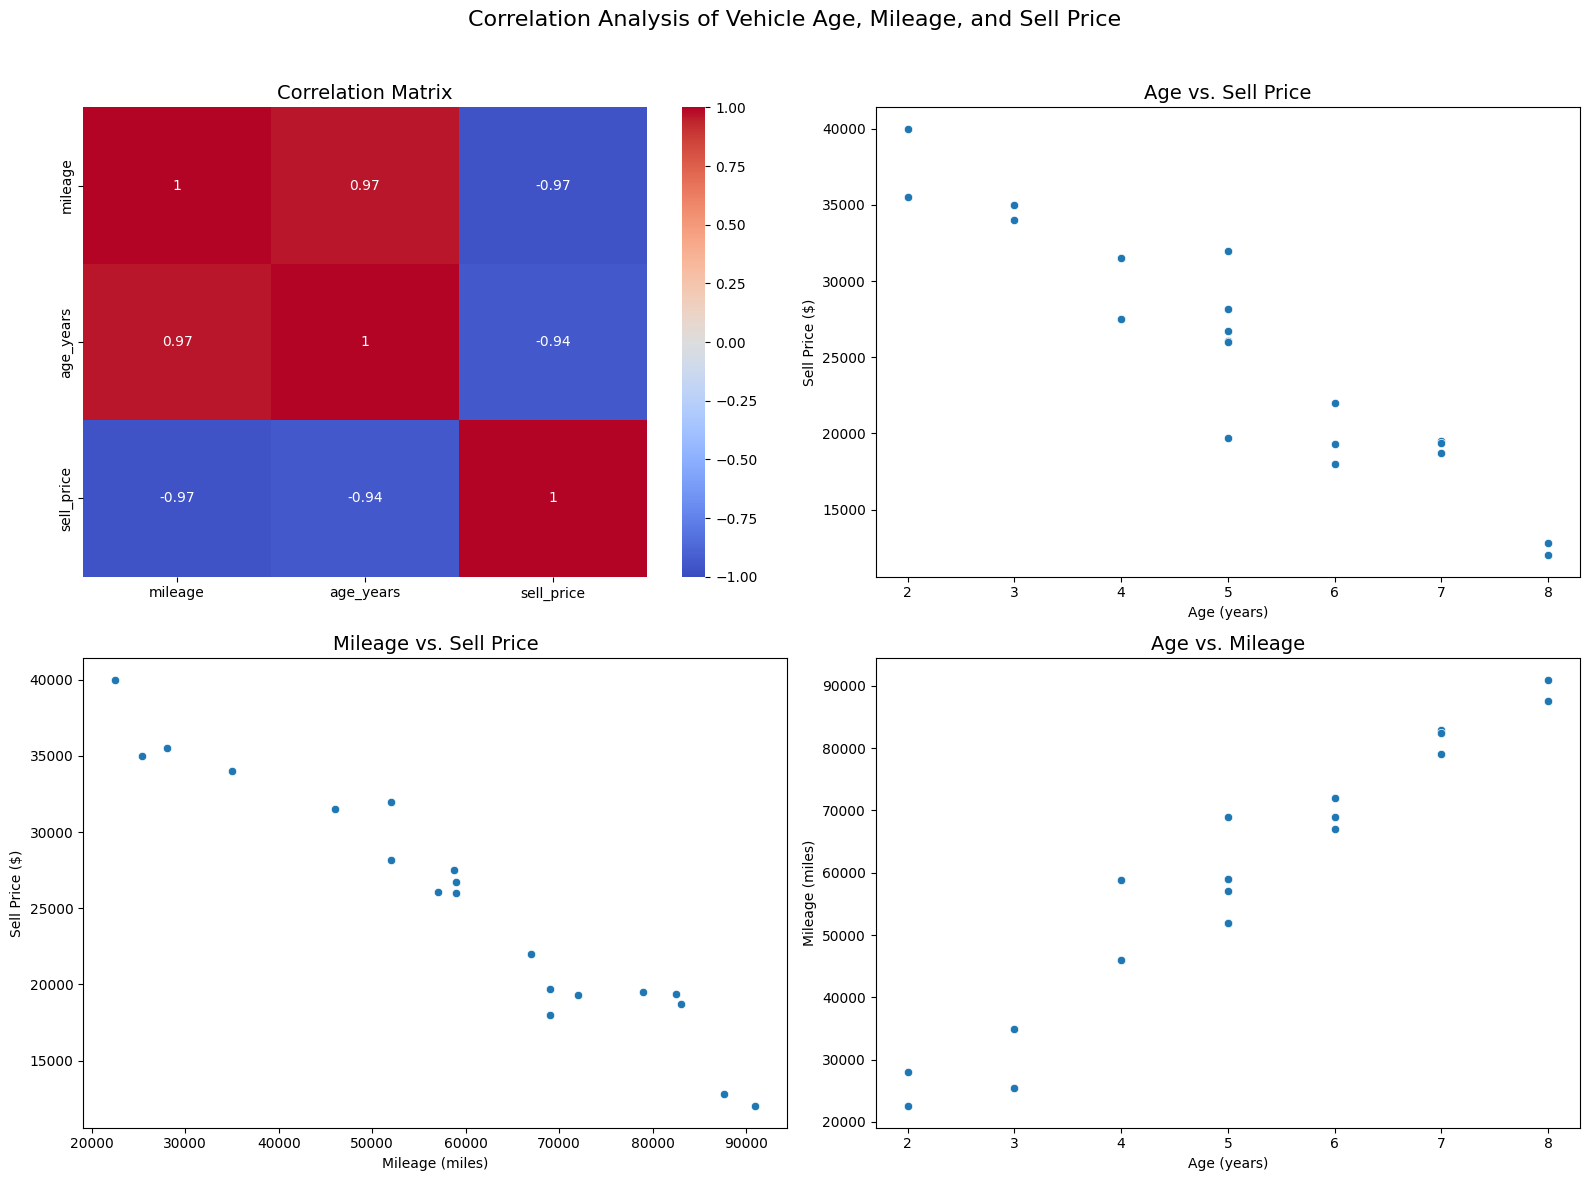

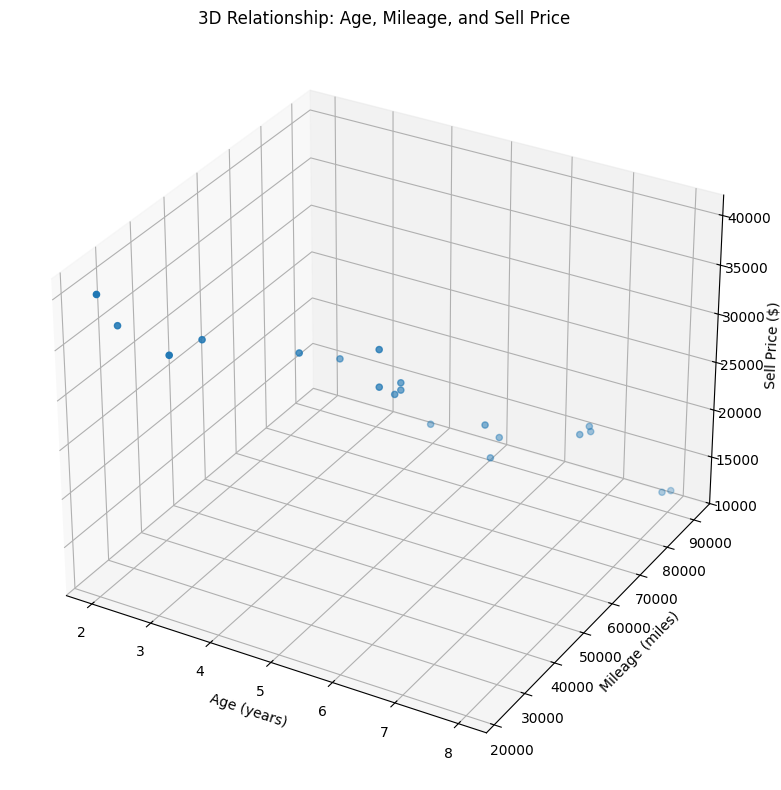

Correlation coefficients:
             mileage  age_years  sell_price
mileage     1.000000   0.968290   -0.967173
age_years   0.968290   1.000000   -0.941522
sell_price -0.967173  -0.941522    1.000000


In [16]:
from sklearn.datasets import make_regression

# Create correlation plots
plt.figure(figsize=(16, 12))

# 1. Correlation matrix heatmap
plt.subplot(2, 2, 1)
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=14)

# 2. Scatter plot: Age vs. Price
plt.subplot(2, 2, 2)
sns.scatterplot(x='age_years', y='sell_price', data=df)
plt.title('Age vs. Sell Price', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Sell Price ($)')

# 3. Scatter plot: Mileage vs. Price
plt.subplot(2, 2, 3)
sns.scatterplot(x='mileage', y='sell_price', data=df)
plt.title('Mileage vs. Sell Price', fontsize=14)
plt.xlabel('Mileage (miles)')
plt.ylabel('Sell Price ($)')

# 4. Scatter plot: Age vs. Mileage
plt.subplot(2, 2, 4)
sns.scatterplot(x='age_years', y='mileage', data=df)
plt.title('Age vs. Mileage', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Mileage (miles)')

# Add a main title
plt.suptitle('Correlation Analysis of Vehicle Age, Mileage, and Sell Price', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show plot
plt.show()

# Optional: 3D scatter plot to visualize all three variables together
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['age_years'], df['mileage'], df['sell_price'])
ax.set_xlabel('Age (years)')
ax.set_ylabel('Mileage (miles)')
ax.set_zlabel('Sell Price ($)')
ax.set_title('3D Relationship: Age, Mileage, and Sell Price')
plt.tight_layout()
plt.show()

# Print correlation values
print("Correlation coefficients:")
print(correlation_matrix)

### Without Random_state

In [22]:
X = df.drop('sell_price', axis='columns') # or axis= 1 
y = df['sell_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3)  # Without random_state=42

In [23]:
lg_model = LinearRegression()
lg_model.fit(X_train, y_train)

LinearRegression()

In [24]:
X_test

,mileage,age_years
0,69000,6
6,52000,5
16,28000,2
1,35000,3
10,83000,7
11,79000,7


In [25]:
lg_model.predict(X_test)

array([21422.43988934, 27383.00865988, 37818.54828542, 34615.81902824,
       16289.2229728 , 17392.35877815])

In [26]:
lg_model.score(X_test, y_test)

0.8596122801162173

### With Random_state

In [27]:
r_X_train, r_X_test, r_y_train, r_y_test = train_test_split(X, y, test_size= 0.3, random_state=10)

In [28]:
lg_model = LinearRegression()
lg_model.fit(r_X_train, r_y_train)

LinearRegression()

In [29]:
r_X_test

,mileage,age_years
7,72000,6
10,83000,7
5,59000,5
6,52000,5
3,22500,2
18,87600,8


In [36]:
pred = lg_model.predict(r_X_test)
pred

array([20668.52722622, 16762.33242213, 25160.18381011, 27209.30003936,
       37903.32633702, 14729.61531335])

In [35]:
lg_model.score(r_X_test, r_y_test)

0.921242248377633

### Rounded

In [34]:
score = lg_model.score(r_X_test, r_y_test)
formatted_score = f"{score:.4f}"
print(formatted_score)

0.9212


In [49]:
pred_data = pd.DataFrame({'r_y_test_mile': r_y_test, 'r_X_test_age': r_X_test.age_years, 'Predicted': pred})

In [50]:
pred_data

,r_y_test_mile,r_X_test_age,Predicted
7,19300,6,20668.527226
10,18700,7,16762.332422
5,26750,5,25160.183810
6,32000,5,27209.300039
3,40000,2,37903.326337
18,12800,8,14729.615313


In [51]:
pred_data.to_csv('predictions.csv', index=False)